# V2R mega genome map

One consensus ideogram: all 5 species stacked per chromosome, so hotspots line up across genomes. Same coverage-class coloring as `plot_genome.py`, just faceted by species instead of run per-species.

In [1]:

from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CURATION = "/scratchdata1/users/a1864358/sanders_lab/asm/files/annotation/eviann_results/hmaj/curation"
ASM = "/hpcfs/users/a1864358/sanders_lab/asm/files/final-asms/10-{sp}-final.renamed.fa.fai"
SPECIES = ["hmaj", "hcy", "hcure", "hcurw", "horn"]
CHROMS = [f"ch{i}" for i in range(1, 9)] + ["chZ"]

# these assemblies have ch2 on the opposite strand of the reference orientation
# -- the V2R array sits at the far end instead of the near end. Flip position
# (not the chromosome itself) just for display, so arrays line up across species.
FLIP = {("hcy", "ch2"), ("hcurw", "ch2"), ("horn", "ch2")}

INK, MUTED, CHROM_FILL = "#1c1c1c", "#8a8a8a", "#e8e6e1"
CLASSES = ("intact", "partial", "fragmented", "not_assessed")
COLOUR = {"intact": "#2f6f4e", "partial": "#c98a2b",
          "fragmented": "#b4553f", "not_assessed": "#a8a29a"}


In [2]:

# one gene per point, represented by its most complete isoform -- same rule as plot_genome.py
CHROM_SET = set(CHROMS)

def load_species(sp):
    genes = {}
    with open(f"{CURATION}/results/{sp}/v2r_genes.tsv") as fh:
        header = fh.readline().rstrip("\n").split("\t")
        idx = {name: i for i, name in enumerate(header)}
        for line in fh:
            r = line.rstrip("\n").split("\t")
            gid = r[idx["gene_id"]]
            if gid == "NA":
                continue
            cls = r[idx["coverage_class"]]
            pos = (int(r[idx["tx_start"]]) + int(r[idx["tx_end"]])) // 2
            prev = genes.get(gid)
            if prev is None or CLASSES.index(cls) < CLASSES.index(prev[2]):
                genes[gid] = (r[idx["chrom"]], pos, cls)

    lengths = {}
    with open(ASM.format(sp=sp)) as fh:
        for line in fh:
            f = line.split("\t")
            lengths[f[0]] = int(f[1])

    on_chrom, on_scaffold = defaultdict(list), []
    for c, pos, cls in genes.values():
        (on_chrom[c] if c in CHROM_SET else on_scaffold).append((pos, cls))
    return lengths, on_chrom, on_scaffold, len(genes)

DATA = {sp: load_species(sp) for sp in SPECIES}
{sp: DATA[sp][3] for sp in SPECIES}  # sanity check: gene totals


{'hmaj': 661, 'hcy': 433, 'hcure': 418, 'hcurw': 513, 'horn': 425}

wrote /scratchdata1/users/a1864358/sanders_lab/asm/files/annotation/eviann_results/hmaj/curation/results/v2r_mega_genome_map.png
wrote /scratchdata1/users/a1864358/sanders_lab/asm/files/annotation/eviann_results/hmaj/curation/results/v2r_mega_genome_map.pdf


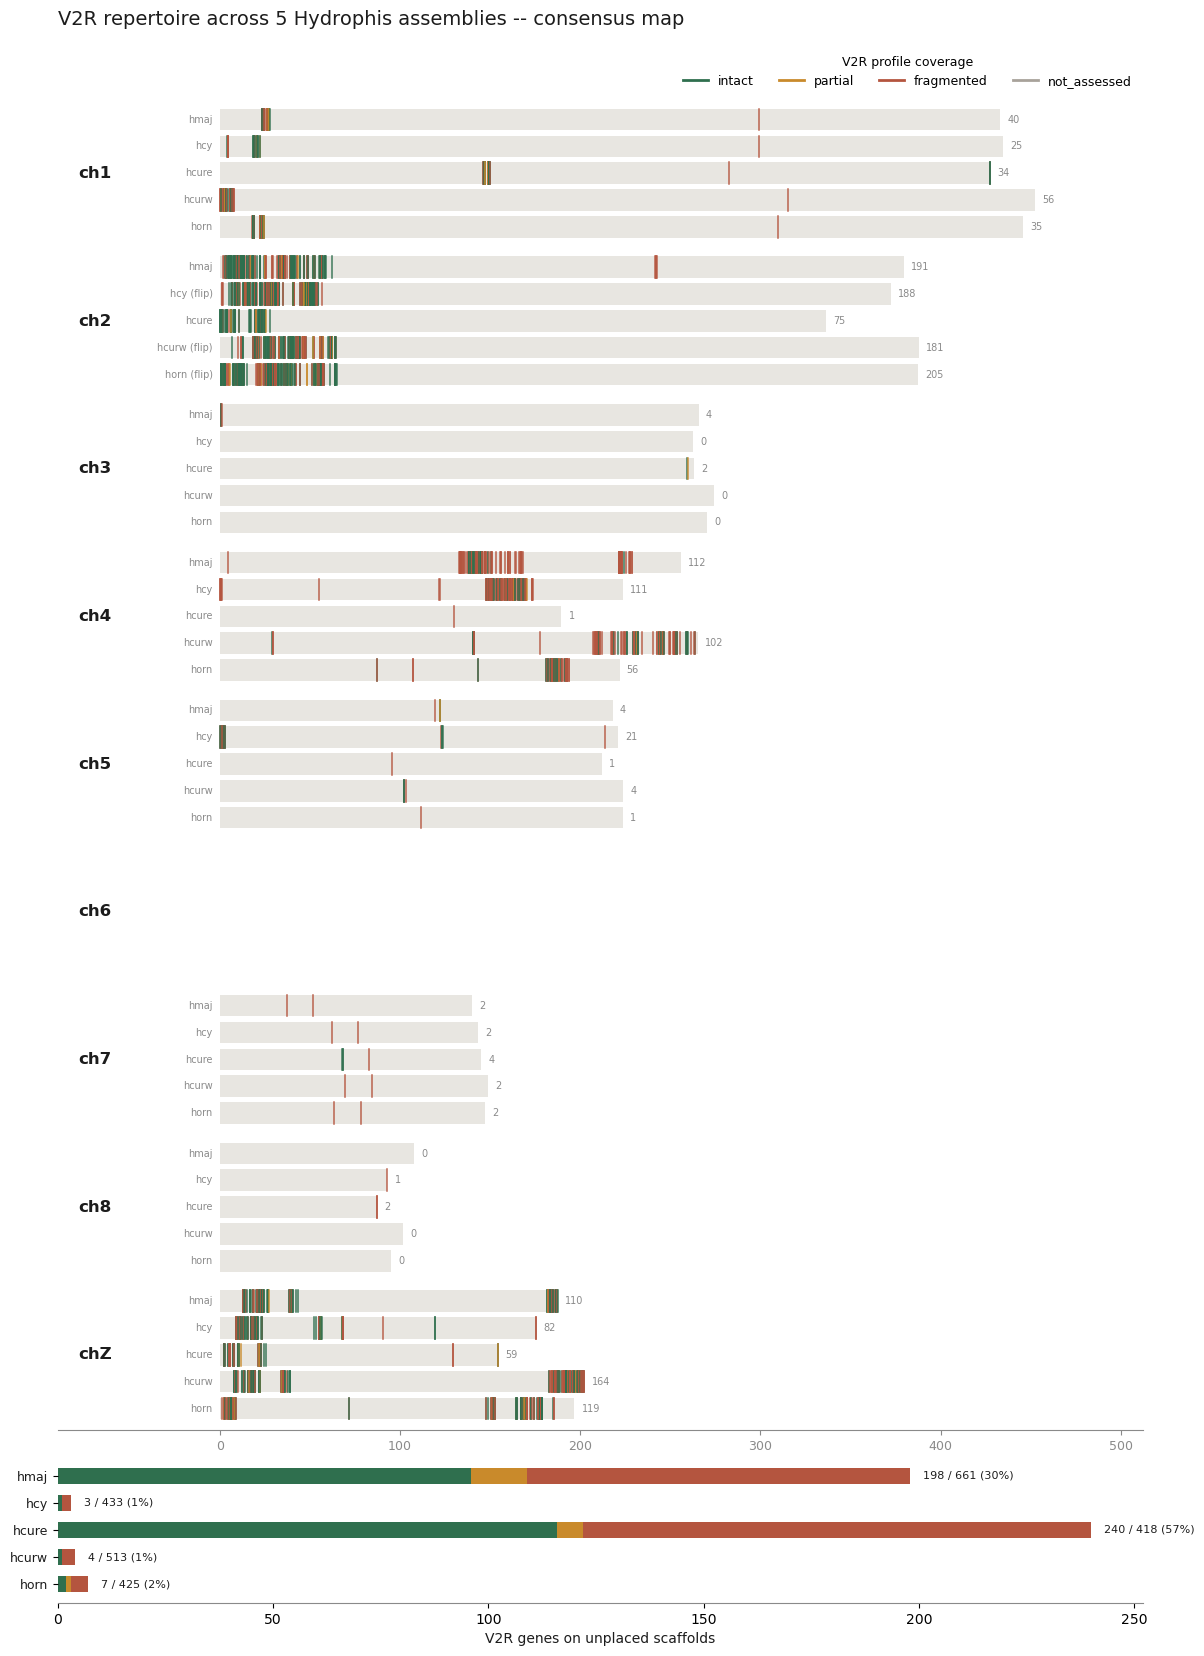

In [3]:

# --- draw: one row per chromosome, one thin lane per species inside it -------
scale = 1e6  # Mb
n_lane = len(SPECIES)
lane_h = 0.8           # bar height, in "lane" units (1 lane = 1 unit)
chrom_gap = 1.5         # blank lanes between chromosome groups

max_len = max(l for sp in SPECIES for c, l in DATA[sp][0].items() if c in CHROMS) / scale
n_rows = len(CHROMS) * n_lane + (len(CHROMS) - 1) * chrom_gap

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(14, 0.32 * n_rows + 2),
    gridspec_kw={"height_ratios": [n_rows, n_lane + 1], "hspace": 0.4 / (n_rows / n_lane)})

y = 0
for c in CHROMS:
    for i, sp in enumerate(SPECIES):
        lengths, on_chrom, _, _ = DATA[sp]
        if c not in lengths:
            continue
        ly = y - i
        width = lengths[c] / scale
        flipped = (sp, c) in FLIP
        ax.add_patch(plt.Rectangle((0, ly - lane_h / 2), width, lane_h,
                                    facecolor=CHROM_FILL, edgecolor="none", zorder=1))
        for pos, cls in on_chrom.get(c, []):
            x = width - pos / scale if flipped else pos / scale
            ax.plot([x, x], [ly - lane_h / 2, ly + lane_h / 2],
                    color=COLOUR.get(cls, MUTED), lw=1.1, alpha=0.9, zorder=2)
        label = sp + " (flip)" if flipped else sp
        ax.text(-4, ly, label, ha="right", va="center", fontsize=7, color=MUTED)
        ax.text(width + 4, ly, f"{len(on_chrom.get(c, []))}", ha="left", va="center",
                fontsize=7, color=MUTED)
    ax.text(-60, y - (n_lane - 1) / 2, c, ha="right", va="center",
            fontsize=12, color=INK, fontweight="bold")
    y -= n_lane - 1 + chrom_gap

ax.set_xlim(-90, max_len + 60)
ax.set_ylim(y + chrom_gap - lane_h, lane_h + 2)   # +2 headroom so the legend clears row 1
ax.set_yticks([])
ax.set_xlabel("position (Mb)", fontsize=10, color=INK)
ax.set_title("V2R repertoire across 5 Hydrophis assemblies -- consensus map",
             fontsize=14, color=INK, pad=14, loc="left")
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(handles=[Line2D([], [], color=COLOUR[c], lw=2, label=c) for c in CLASSES],
          loc="upper right", frameon=False, fontsize=9, ncol=4,
          title="V2R profile coverage", title_fontsize=9)

# unplaced scaffolds: one stacked bar per species
for i, sp in enumerate(SPECIES):
    _, _, on_scaffold, n_genes = DATA[sp]
    counts = defaultdict(int)
    for _pos, cls in on_scaffold:
        counts[cls] += 1
    left = 0
    for c in CLASSES:
        if counts[c]:
            ax2.barh(i, counts[c], left=left, height=0.6, color=COLOUR[c])
            left += counts[c]
    ax2.text(left + 3, i, f"{left} / {n_genes} ({100 * left / n_genes:.0f}%)",
              va="center", fontsize=8, color=INK)
ax2.set_yticks(range(n_lane))
ax2.set_yticklabels(SPECIES, fontsize=9, color=INK)
ax2.set_ylim(n_lane - 0.3, -0.7)
ax2.set_xlabel("V2R genes on unplaced scaffolds", fontsize=10, color=INK)
for side in ("top", "right", "left"):
    ax2.spines[side].set_visible(False)
ax2.spines["bottom"].set_color(MUTED)

fig.savefig(f"{CURATION}/results/v2r_mega_genome_map.png", dpi=200, bbox_inches="tight", facecolor="white")
fig.savefig(f"{CURATION}/results/v2r_mega_genome_map.svg", bbox_inches="tight", facecolor="white")
fig.savefig(f"{CURATION}/results/v2r_mega_genome_map.pdf", bbox_inches="tight", facecolor="white")
print("wrote", f"{CURATION}/results/v2r_mega_genome_map.png")
print("wrote", f"{CURATION}/results/v2r_mega_genome_map.pdf")
